# ***`Libraries`***

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# ***`Read Data`***

In [18]:
df = pd.read_excel('Preprocessed Dataset.xlsx')
df

,Followers,Total Revenue,Years Joined,Rating Quality,Good Review,Med Review,Bad Review
0,0.060135,0.008283,1.806134,0.453583,0.631159,1.618767,1.080557
1,-0.071209,-0.047449,-1.814746,0.037897,-0.497662,1.196371,0.308262
2,-0.009052,0.008283,0.599174,0.424516,0.641790,-0.172147,1.292087
3,-0.046442,0.008283,0.599174,-0.066678,-0.096943,0.975558,1.761924
4,-0.072807,-0.053651,-0.607786,0.144730,0.344560,-0.269972,0.509950
...,...,...,...,...,...,...,...
1794,-0.072008,-0.054545,-0.004306,0.165504,-0.858078,-0.724797,-0.707270
1795,-0.075683,-0.054932,-1.814746,-2.227588,-1.622587,-0.724797,-0.707270
1796,-0.075683,-0.054932,-1.211266,-3.055399,-2.303363,-0.724797,-0.707270
1797,-0.071129,-0.052300,-1.814746,-0.478144,-0.076643,-0.724797,-0.707270


In [19]:
X = df.values.astype(np.float32)
print("Data shape:", X.shape)

Data shape: (1799, 7)


# ***`Autoencoder`***

In [20]:
import tensorflow as tf
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

input_dim = X.shape[1]  # 7 chiều
latent_dim = 4

# Kiến trúc autoencoder đơn giản
input_layer = Input(shape=(input_dim,), name='input_layer')

# Encoder: Mở rộng đôi chút rồi giảm về latent_dim
encoder_hidden = Dense(8, activation='relu', name='encoder_hidden')(input_layer)
encoder_hidden2 = Dense(6, activation='relu', name='encoder_hidden2')(encoder_hidden)
latent = Dense(latent_dim, activation='relu', name='latent_layer')(encoder_hidden2)

# Decoder: Phục hồi lại kích thước ban đầu từ latent space
decoder_hidden = Dense(6, activation='relu', name='decoder_hidden')(latent)
decoder_hidden2 = Dense(8, activation='relu', name='decoder_hidden2')(decoder_hidden)
output_layer = Dense(input_dim, activation='linear', name='output_layer')(decoder_hidden2)

# Tạo model Autoencoder
autoencoder = Model(inputs=input_layer, outputs=output_layer, name='autoencoder')
autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
autoencoder.summary()


Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 7)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_hidden (Dense)          │ (None, 8)              │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ encoder_hidden2 (Dense)         │ (None, 6)              │            54 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_layer (Dense)            │ (None, 4)              │            28 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_hidden (Dense)          │ (None, 6)              │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_hidden2 (Dense)         │ (None, 8)              │            56 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 7)              │            63 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 295 (1.15 KB)

 Trainable params: 295 (1.15 KB)

 Non-trainable params: 0 (0.00 B)

In [21]:
# import tensorflow as tf
# from tensorflow.keras.layers import Input, Dense
# from tensorflow.keras.models import Model
# from tensorflow.keras.optimizers import Adam

# input_dim = X.shape[1]  # 7 chiều
# latent_dim = 3         # Tầng latent 3 chiều theo yêu cầu

# # Kiến trúc autoencoder theo chuỗi: 7 -> 10 -> 7 -> 5 -> 3 (encoder)
# input_layer = Input(shape=(input_dim,), name='input_layer')

# encoder_hidden1 = Dense(10, activation='relu', name='encoder_hidden1')(input_layer)
# encoder_hidden2 = Dense(7, activation='relu', name='encoder_hidden2')(encoder_hidden1)
# encoder_hidden3 = Dense(5, activation='relu', name='encoder_hidden3')(encoder_hidden2)
# latent = Dense(latent_dim, activation='relu', name='latent_layer')(encoder_hidden3)

# # Decoder: mirror lại kiến trúc của encoder: 3 -> 5 -> 7 -> 10 -> 7 (output)
# decoder_hidden1 = Dense(5, activation='relu', name='decoder_hidden1')(latent)
# decoder_hidden2 = Dense(7, activation='relu', name='decoder_hidden2')(decoder_hidden1)
# decoder_hidden3 = Dense(10, activation='relu', name='decoder_hidden3')(decoder_hidden2)
# output_layer = Dense(input_dim, activation='linear', name='output_layer')(decoder_hidden3)

# # Tạo model Autoencoder
# autoencoder = Model(inputs=input_layer, outputs=output_layer, name='autoencoder')
# autoencoder.compile(optimizer=Adam(learning_rate=0.001), loss='mse')
# autoencoder.summary()


Epoch 1/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.6029 - val_loss: 0.5832
Epoch 2/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5601 - val_loss: 0.5202
Epoch 3/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.5117 - val_loss: 0.3959
Epoch 4/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.4061 - val_loss: 0.3011
Epoch 5/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.3389 - val_loss: 0.2621
Epoch 6/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2848 - val_loss: 0.2225
Epoch 7/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2453 - val_loss: 0.1885
Epoch 8/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2054 - val_loss: 0.1561
Epoch 9/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1719 - val_loss: 0.1269
Epoch 10/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1459 - val_loss: 0.1070
Epoch 11/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1196 - val_loss: 0.0962
Epoch 12/100
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.1

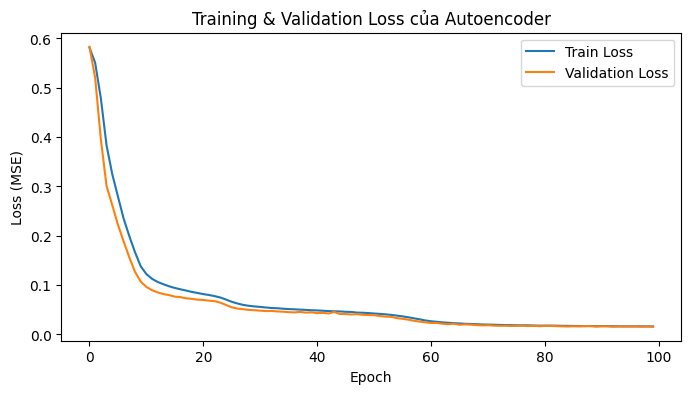

In [22]:
# Cell 3: Huấn luyện mô hình Autoencoder
history = autoencoder.fit(X, X,
                          epochs=100,
                          batch_size=32,
                          validation_split=0.1,
                          verbose=1)

# Vẽ đồ thị loss của quá trình huấn luyện
plt.figure(figsize=(8, 4))
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title("Training & Validation Loss của Autoencoder")
plt.xlabel("Epoch")
plt.ylabel("Loss (MSE)")
plt.legend()
plt.show()


In [23]:
# Cell 4: Trích xuất không gian nhúng (latent space) từ phần encoder
encoder = Model(inputs=input_layer, outputs=latent, name='encoder')
X_embedded = encoder.predict(X)
print("Kích thước không gian nhúng:", X_embedded.shape)


57/57 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Kích thước không gian nhúng: (1799, 4)


# ***`Deep Embedded K-Means`***

In [24]:
# Cell 5: Tối ưu tham số KMeans với GridSearch
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(X_emb, labels):
    sil = silhouette_score(X_emb, labels)
    db = davies_bouldin_score(X_emb, labels)
    ch = calinski_harabasz_score(X_emb, labels)
    return sil, db, ch

param_grid = {
    'init': ['k-means++', 'random'],
}

best_score = -np.inf   # Mục tiêu là tối đa hóa Silhouette Score
best_params = None
results = []

for init_method in param_grid['init']:
    kmeans = KMeans(n_clusters=5, init=init_method, random_state=42)
    labels = kmeans.fit_predict(X_embedded)
    sil, db, ch = evaluate_clustering(X_embedded, labels)
    results.append({
        'init': init_method,
        'silhouette': sil,
        'davies_bouldin': db,
        'calinski_harabasz': ch
    })
    if sil > best_score:
        best_score = sil
        best_params = {'init': init_method}

results_df = pd.DataFrame(results)
print("Kết quả GridSearch cho KMeans trên không gian nhúng:")
print(results_df)
print("\nTham số tối ưu:", best_params)


Kết quả GridSearch cho KMeans trên không gian nhúng:
        init  silhouette  davies_bouldin  calinski_harabasz
0  k-means++    0.316527        1.102648        1504.760498
1     random    0.370794        0.919874        1780.394165

Tham số tối ưu: {'init': 'random'}


In [25]:
# Cell 6: Phân cụm sử dụng KMeans với tham số tối ưu và đánh giá các chỉ số phân cụm
kmeans_best = KMeans(n_clusters=5, init=best_params['init'], random_state=42)
labels_best = kmeans_best.fit_predict(X_embedded)

sil, db, ch = evaluate_clustering(X_embedded, labels_best)
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")
print(f"Calinski-Harabasz Score: {ch:.4f}")


Silhouette Score: 0.3708
Davies-Bouldin Score: 0.9199
Calinski-Harabasz Score: 1780.3942


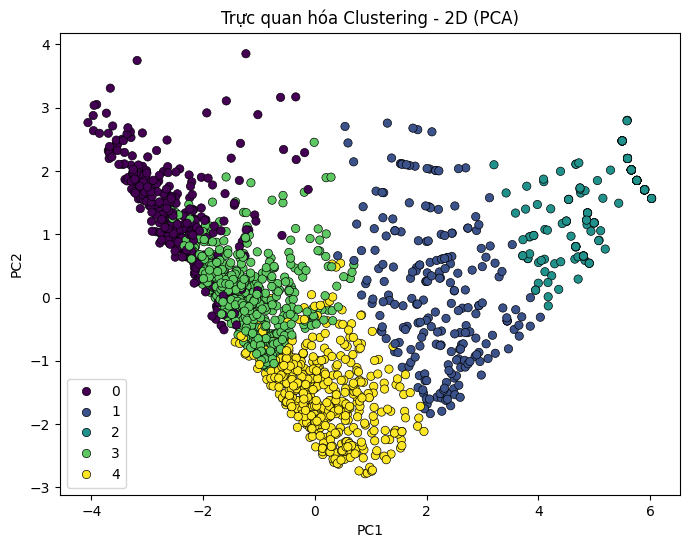

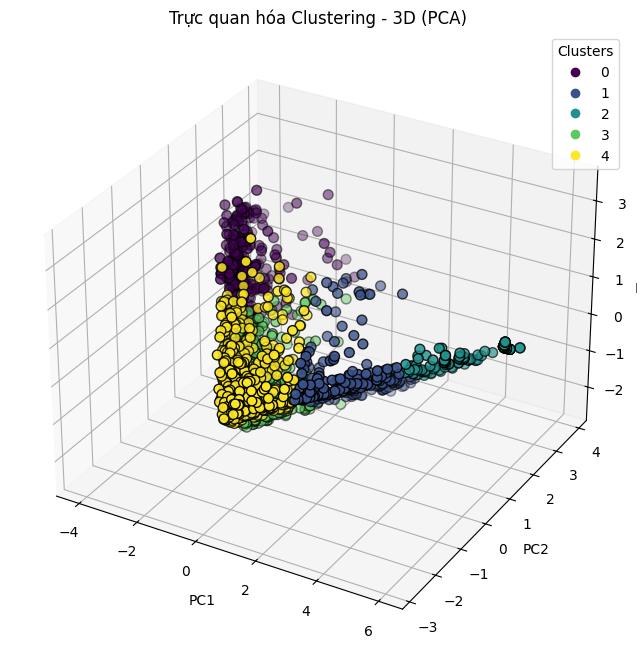

In [26]:
# Cell 7: Trực quan hóa kết quả phân cụm sử dụng PCA (2D và 3D)
from sklearn.decomposition import PCA

# 2D visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_embedded)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels_best, palette='viridis', edgecolor='k', legend='full')
plt.title("Trực quan hóa Clustering - 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 3D visualization
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_embedded)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2], c=labels_best, cmap='viridis', edgecolor='k', s=50)
ax.set_title("Trực quan hóa Clustering - 3D (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()


# ***`Deep Embedded Agglomerative`***

In [27]:
# Cell 5: Tối ưu tham số Agglomerative Clustering trên không gian nhúng
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(X_emb, labels):
    sil = silhouette_score(X_emb, labels)
    db = davies_bouldin_score(X_emb, labels)
    ch = calinski_harabasz_score(X_emb, labels)
    return sil, db, ch

param_grid = {
    'linkage': ['ward', 'complete', 'average', 'single']
}

best_score = -np.inf  # Mục tiêu: tối đa hóa Silhouette Score
best_params = None
results = []

for linkage in param_grid['linkage']:
    try:
        agglo = AgglomerativeClustering(n_clusters=3, linkage=linkage)
        labels = agglo.fit_predict(X_embedded)
        sil, db, ch = evaluate_clustering(X_embedded, labels)
        results.append({
            'linkage': linkage,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })
        if sil > best_score:
            best_score = sil
            best_params = {'linkage': linkage}
    except Exception as e:
        print("Lỗi với linkage", linkage, ":", e)

results_df = pd.DataFrame(results)
print("Kết quả GridSearch cho Agglomerative Clustering trên không gian nhúng:")
print(results_df)
print("\nTham số tối ưu:", best_params)


Kết quả GridSearch cho Agglomerative Clustering trên không gian nhúng:
    linkage  silhouette  davies_bouldin  calinski_harabasz
0      ward    0.361745        0.968959        1499.175781
1  complete    0.369568        0.929205        1600.614014
2   average    0.347989        0.829280        1252.237793
3    single    0.043845        1.021349           3.010825

Tham số tối ưu: {'linkage': 'complete'}


In [28]:
# Cell 6: Áp dụng Agglomerative Clustering với tham số tối ưu và đánh giá
best_linkage = best_params['linkage']
agglo_best = AgglomerativeClustering(n_clusters=3, linkage=best_linkage)
labels_best = agglo_best.fit_predict(X_embedded)

sil, db, ch = evaluate_clustering(X_embedded, labels_best)
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")
print(f"Calinski-Harabasz Score: {ch:.4f}")


Silhouette Score: 0.3696
Davies-Bouldin Score: 0.9292
Calinski-Harabasz Score: 1600.6140


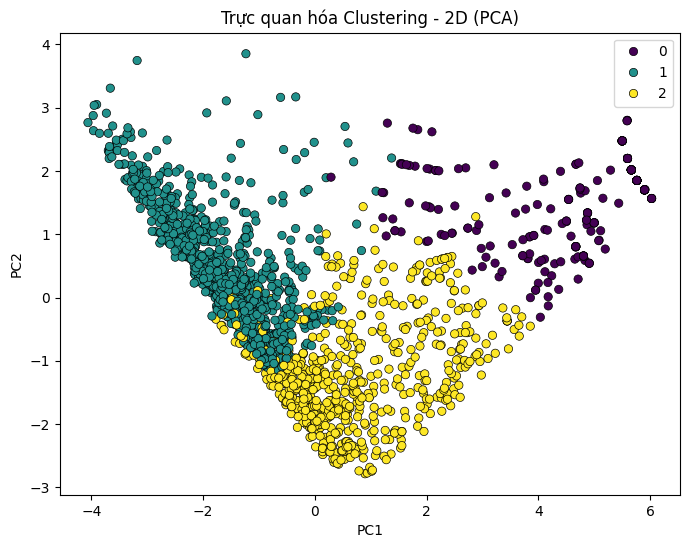

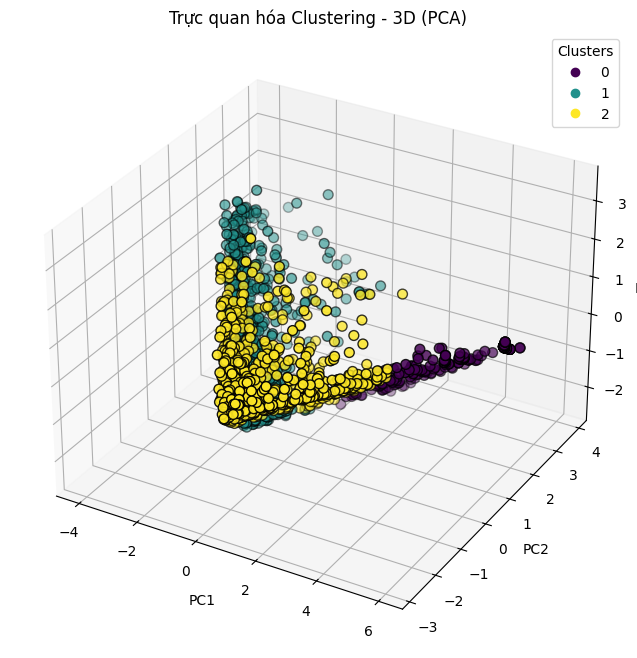

In [29]:
# Cell 7: Trực quan hóa kết quả phân cụm sử dụng PCA (2D và 3D)
from sklearn.decomposition import PCA

# 2D Visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_embedded)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels_best, palette='viridis', legend='full', edgecolor='k')
plt.title("Trực quan hóa Clustering - 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 3D Visualization
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_embedded)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2], c=labels_best, cmap='viridis', edgecolor='k', s=50)
ax.set_title("Trực quan hóa Clustering - 3D (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()


# ***`Gaussian Mixture Model (GMM)`***

In [30]:
# Cell 5: Tối ưu tham số cho GMM với GridSearch
from sklearn.mixture import GaussianMixture
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

def evaluate_clustering(X_emb, labels):
    sil = silhouette_score(X_emb, labels)
    db = davies_bouldin_score(X_emb, labels)
    ch = calinski_harabasz_score(X_emb, labels)
    return sil, db, ch

param_grid = {
    'covariance_type': ['full', 'diag', 'spherical', 'tied'],
}

best_score = -np.inf  # Mục tiêu tối đa hóa Silhouette Score
best_params = None
results = []

for cov_type in param_grid['covariance_type']:
        # Khởi tạo GMM với số cụm = 5
        gmm = GaussianMixture(n_components=3, covariance_type=cov_type, random_state=42)
        gmm.fit(X_embedded)
        labels = gmm.predict(X_embedded)
        sil, db, ch = evaluate_clustering(X_embedded, labels)
        results.append({
            'covariance_type': cov_type,
            'silhouette': sil,
            'davies_bouldin': db,
            'calinski_harabasz': ch
        })
        if sil > best_score:
            best_score = sil
            best_params = {'covariance_type': cov_type}

results_df = pd.DataFrame(results)
print("Kết quả GridSearch cho GMM trên không gian nhúng:")
print(results_df)
print("\nTham số tối ưu:", best_params)


Kết quả GridSearch cho GMM trên không gian nhúng:
  covariance_type  silhouette  davies_bouldin  calinski_harabasz
0            full    0.172583        1.461479         762.558105
1            diag    0.240582        1.204832         960.295532
2       spherical    0.380401        0.916213        1795.883911
3            tied    0.323562        0.953108        1314.033081

Tham số tối ưu: {'covariance_type': 'spherical'}


In [31]:
# Cell 6: Áp dụng GMM với tham số tối ưu và đánh giá kết quả phân cụm
best_cov_type = best_params['covariance_type']

gmm_best = GaussianMixture(n_components=3, covariance_type=best_cov_type, random_state=42)
gmm_best.fit(X_embedded)
labels_best = gmm_best.predict(X_embedded)

sil, db, ch = evaluate_clustering(X_embedded, labels_best)
print(f"Silhouette Score: {sil:.4f}")
print(f"Davies-Bouldin Score: {db:.4f}")
print(f"Calinski-Harabasz Score: {ch:.4f}")


Silhouette Score: 0.3804
Davies-Bouldin Score: 0.9162
Calinski-Harabasz Score: 1795.8839


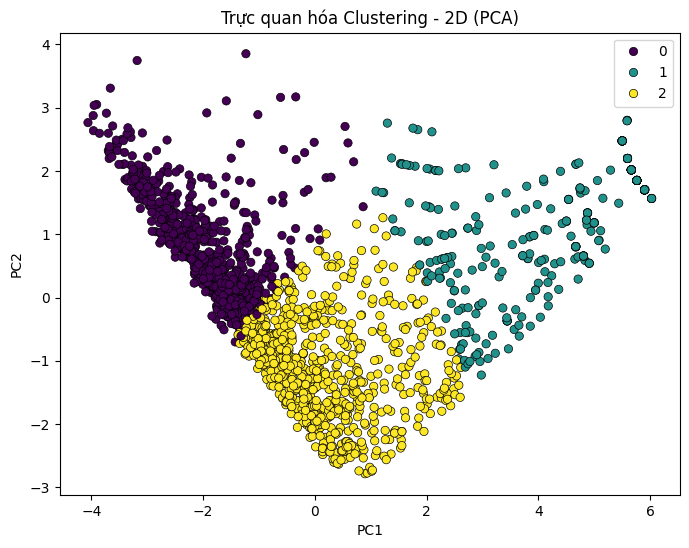

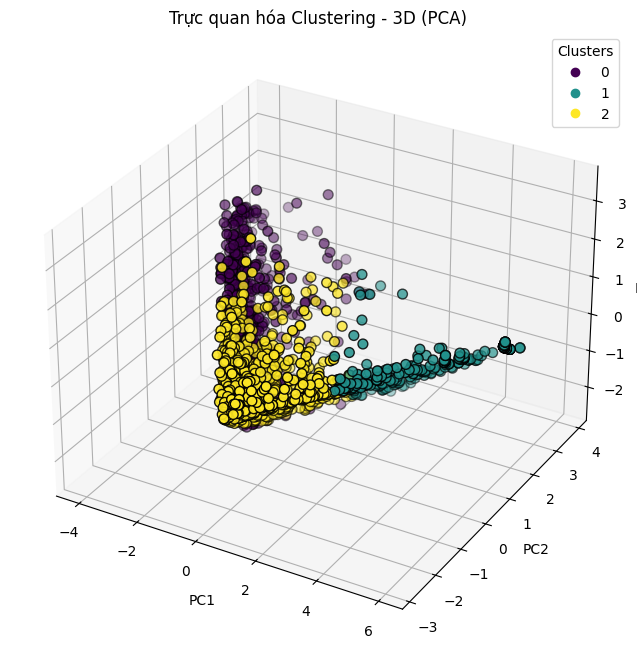

In [32]:
# Cell 7: Trực quan hóa kết quả phân cụm sử dụng PCA (2D và 3D)
from sklearn.decomposition import PCA

# 2D Visualization
pca_2d = PCA(n_components=2)
X_2d = pca_2d.fit_transform(X_embedded)
plt.figure(figsize=(8,6))
sns.scatterplot(x=X_2d[:, 0], y=X_2d[:, 1], hue=labels_best, palette='viridis', legend='full', edgecolor='k')
plt.title("Trực quan hóa Clustering - 2D (PCA)")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 3D Visualization
pca_3d = PCA(n_components=3)
X_3d = pca_3d.fit_transform(X_embedded)
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(10,8))
ax = fig.add_subplot(111, projection='3d')
scatter = ax.scatter(X_3d[:,0], X_3d[:,1], X_3d[:,2], c=labels_best, cmap='viridis', edgecolor='k', s=50)
ax.set_title("Trực quan hóa Clustering - 3D (PCA)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
plt.legend(*scatter.legend_elements(), title="Clusters")
plt.show()
